<a href="https://colab.research.google.com/github/MDreshma786/MDreshma786/blob/main/project_minior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,810 (737.54 KB)

 Trainable params: 188,810 (737.54 KB)

 Non-trainable params: 0 (0.00 B)

(50000, 32, 32, 3) (50000, 10)
(10000, 32, 32, 3) (10000, 10)
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - accuracy: 0.3890 - loss: 1.6714 - val_accuracy: 0.5211 - val_loss: 1.3292
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 86ms/step - accuracy: 0.5340 - loss: 1.3086 - val_accuracy: 0.5979 - val_loss: 1.1430
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.5916 - loss: 1.1555 - val_accuracy: 0.6190 - val_loss: 1.0754
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6292 - loss: 1.0523 - val_accuracy: 0.6498 - val_loss: 0.9982
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.6599 - loss: 0.9750 - val_accuracy: 0.6750 - val_loss: 0.9216
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 85ms/step - accuracy: 0.6804 - loss: 0.9164 - val_accuracy: 0.6927 - val_loss: 0.8848
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.7002 - loss: 0.8661 - val_accuracy: 0.7012 - val_loss: 0.8652
Epoch 8/10
782/782 ━━━━━━━━━

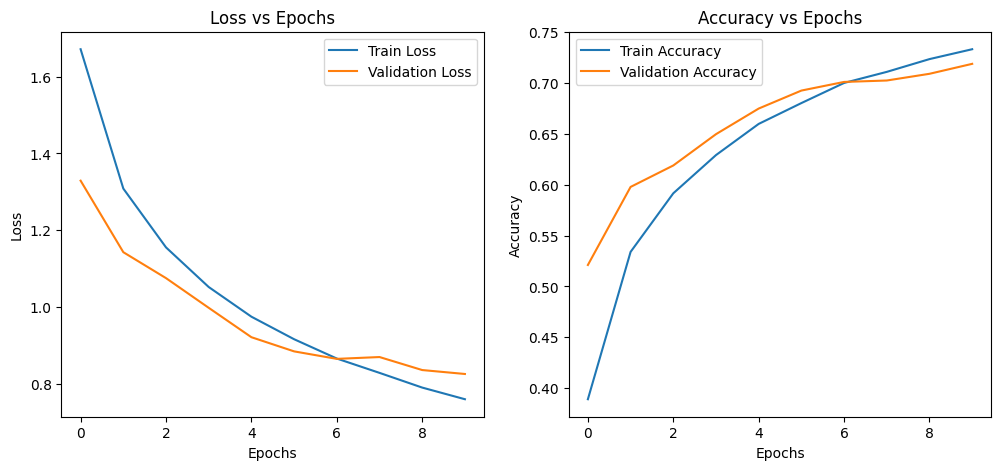

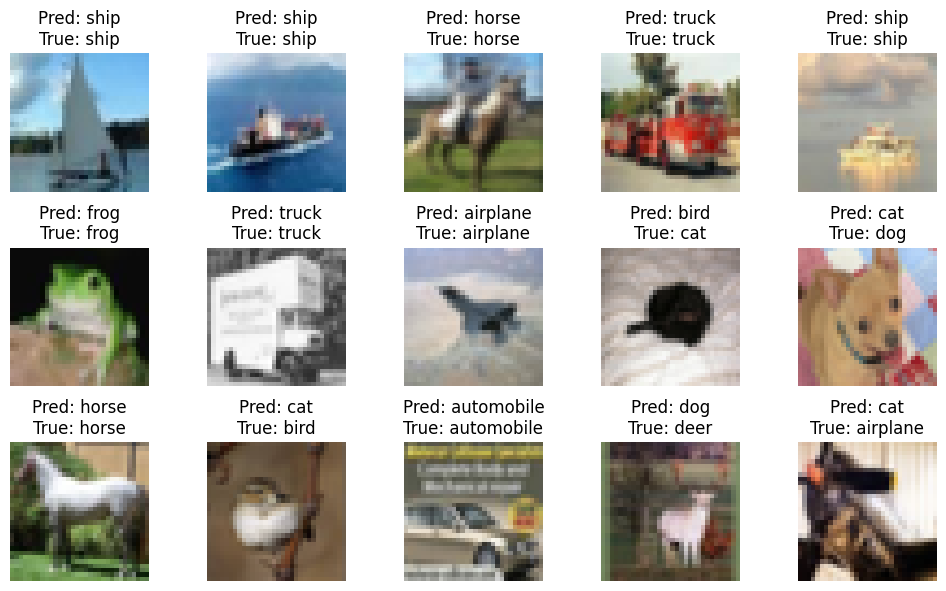

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Dataset shapes
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

# Build CNN Model
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred = model.predict(x_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names
))

# Confusion Matrix
conf_matrix = confusion_matrix(
    y_true_classes,
    y_pred_classes
)

print("Confusion Matrix:\n", conf_matrix)

# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

# Sample Predictions
def plot_sample_predictions():
    fig, axes = plt.subplots(3, 5, figsize=(10, 6))
    axes = axes.ravel()

    for i in range(15):
        index = np.random.randint(0, len(x_test))

        axes[i].imshow(x_test[index])
        axes[i].set_title(
            f"Pred: {class_names[y_pred_classes[index]]}\n"
            f"True: {class_names[y_true_classes[index]]}"
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

plot_sample_predictions()

In [ ]:
!pip install gradio


In [ ]:
import gradio as gr
import tensorflow as tf
model=tf.keras.load_model("cifar10_model.h5")

AttributeError: module 'tensorflow.keras' has no attribute 'load_model'